# Detecção de artefatos de dupla compressão

Implementação do artigo:

[1] A. C. Popescu e H. Farid, “Statistical Tools for Digital Forensics”, em Information Hiding, vol. 3200, J. Fridrich, Org., Berlin, Heidelberg: Springer Berlin Heidelberg, 2004, p. 128–147. doi: 10.1007/978-3-540-30114-1_10.

Autor: Paulo Max Gil Innocencio Reis 

Email: paulo.pmgir@pf.gov.br

Serviço de Perícias em Audiovisual e Eletrônicos - INC/DITEC

*Dupla compressão JPEG insere artegatos periódico nos histogramas dos coeficientes JPEG quantizados*


# Importação de pacotes

In [2]:
!pip install plotly --proxy http://proxy.ditec.pf.gov.br:3128

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import jpegio as jio
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import os
from jinja2 import Template
import glob

# Função detecção. Para cada grupo de coeicientes JPEG, gera os histogramas e curvas de detecção.

In [9]:
def histdct(image_path, dctmin, dctmax, output_dir='./output'):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print("Criando a pasta de saída. Para garantir navegabilidade, certifique-se de copiar os arquivos 'index.html' e 'script.js' correspondentes para a pasta.")
    else:
        for html_file in glob.glob(os.path.join(output_dir, "*.html")):
            if os.path.basename(html_file) != "index.html":
                os.remove(html_file)  # Apaga os arquivos HTML, exceto 'index.html'
   
    # Leitura da imagem utilizando jpegio
    I = jio.read(image_path)
    
    # Extração dos coeficientes DCT
    coefLum = I.coef_arrays[0]
    coefCrom1 = I.coef_arrays[1]
    coefCrom2 = I.coef_arrays[2]
    
    # Extração das tabelas de quantização
    qtLum = I.quant_tables[0]
    qtCrom = I.quant_tables[1]

    print(qtLum)
    
    ordem = np.array([
        [1,  2,  6,  7, 15, 16, 28, 29],
        [3,  5,  8, 14, 17, 27, 30, 43],
        [4,  9, 13, 18, 26, 31, 42, 44],
        [10, 12, 19, 25, 32, 41, 45, 54],
        [11, 20, 24, 33, 40, 46, 53, 55],
        [21, 23, 34, 39, 47, 52, 56, 61],
        [22, 35, 38, 48, 51, 57, 60, 62],
        [36, 37, 49, 50, 58, 59, 63, 64]
    ])
    
    hist_files = []
    deteccao_files = []

    for n, cont in enumerate(range(dctmin, dctmax + 1), start=1):
        ni, nj = np.where(ordem == cont)
        ni, nj = int(ni[0]), int(nj[0])
        
        qt = qtLum[ni, nj]
        DCT_I = coefLum[ni::8, nj::8] * qt
        
        hist_range = np.arange(-500*qt, 500*qt + qt, qt)
        His, _ = np.histogram(DCT_I, bins=hist_range)

        LHis = np.log(His + 1e-10)
        df2 = np.diff(LHis, n=2)
        
        dummy = np.abs(np.fft.fft(df2))**2
        
        # Plotando com matplotlib para verificação imediata
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.bar(hist_range[:-1], His, width=qt)
        plt.title('Histograma dos Coeficientes DCT Ajustados')
        plt.subplot(1, 2, 2)
        plt.plot(dummy/np.median(dummy))
        plt.title(f'Coeficiente DCT: {dctmin + n - 1}')
        plt.axis([0, 1000, 0, 600])
        plt.show()

        # Criando gráficos interativos com plotly
        hist_filename = f"{output_dir}/hist_{dctmin + n - 1}.html"
        fig = go.Figure()
        fig.add_trace(go.Bar(x=hist_range[:-1], y=His, name='Histograma'))
        fig.update_layout(
            title=f'Coeficiente DCT: {dctmin + n - 1}',
            xaxis_title='Bins',
            yaxis_title='Valores',
            showlegend=True
        )
        fig.write_html(hist_filename)
        hist_files.append(hist_filename)

        deteccao_filename = f"{output_dir}/deteccao_{dctmin + n - 1}.html"
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=np.arange(len(dummy)), y=dummy/np.median(dummy), name='FFT Normalizada', line=dict(color='red')))
        fig.update_layout(
            title=f'Detecção: {dctmin + n - 1}',
            xaxis_title='d-fft',
            yaxis=dict(title='Valores', range=[0, 600]),
            showlegend=True,
            margin=dict(l=40, r=20, t=40, b=40)
        )
        fig.write_html(deteccao_filename)
        deteccao_files.append(deteccao_filename)

    

# Aplicação: Nome da imagem, coeficientes inicial e final

[[ 2  2  2  2  3  4  5  6]
 [ 2  2  2  2  3  4  5  6]
 [ 2  2  2  2  4  5  7  9]
 [ 2  2  2  4  5  7  9 12]
 [ 3  3  4  5  8 10 12 12]
 [ 4  4  5  7 10 12 12 12]
 [ 5  5  7  9 12 12 12 12]
 [ 6  6  9 12 12 12 12 12]]


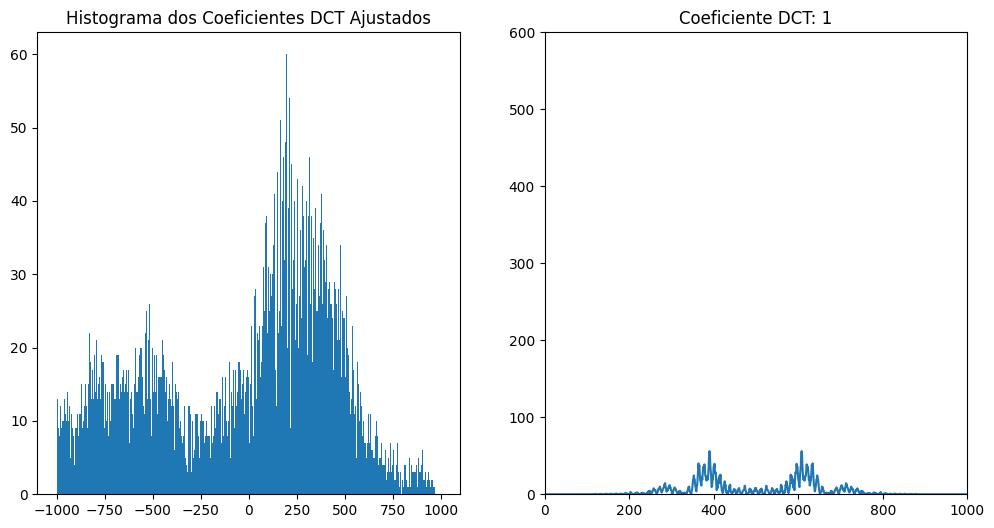

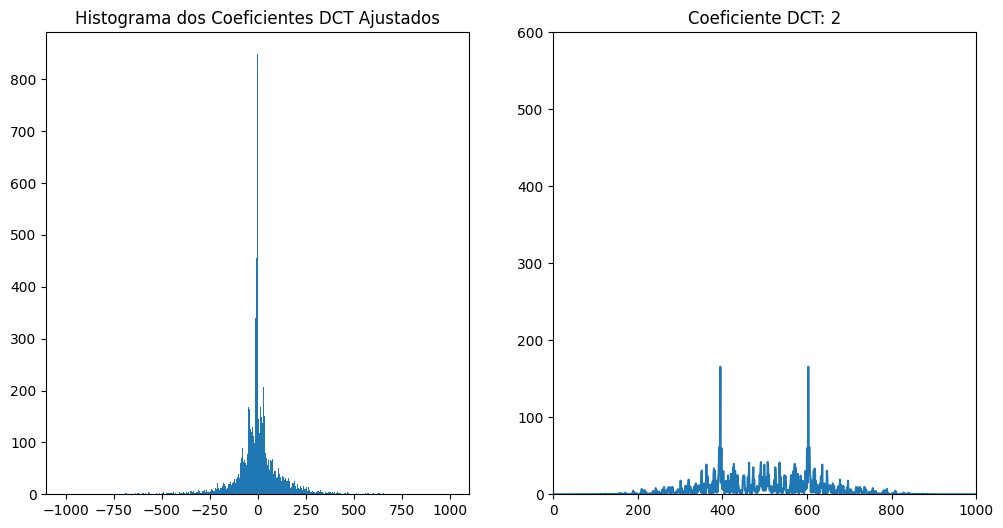

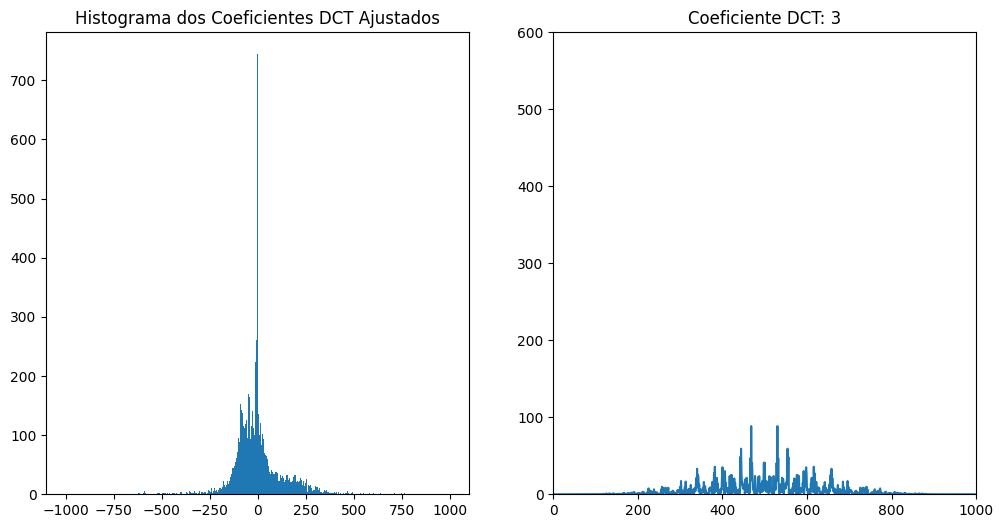

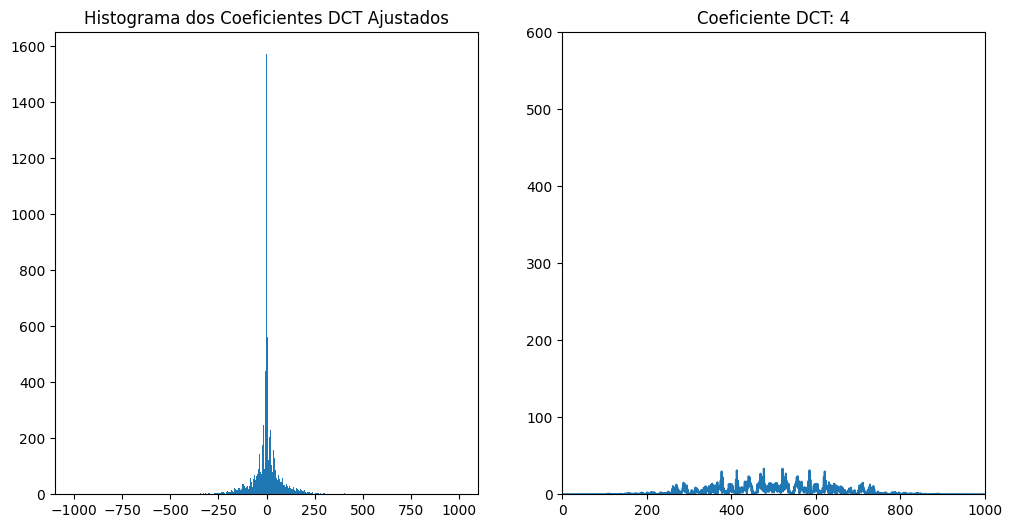

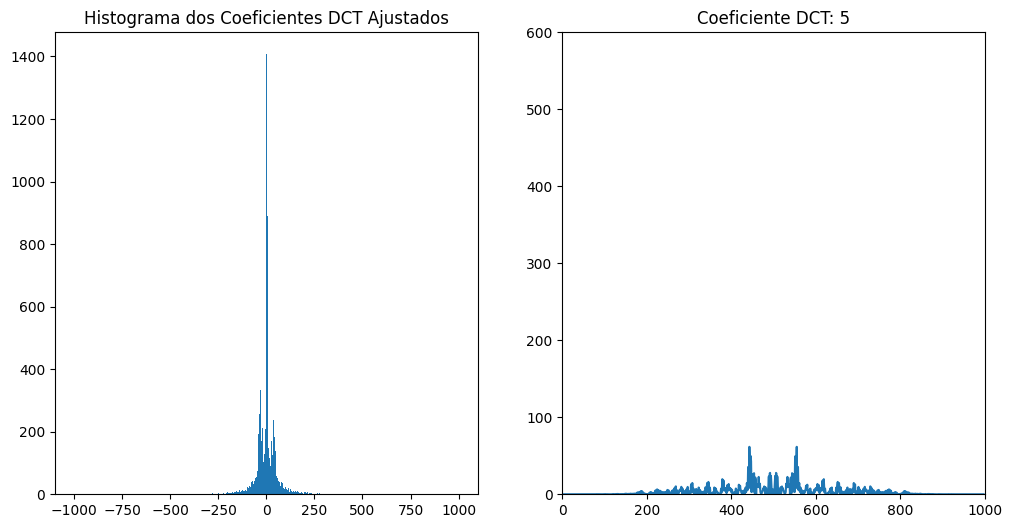

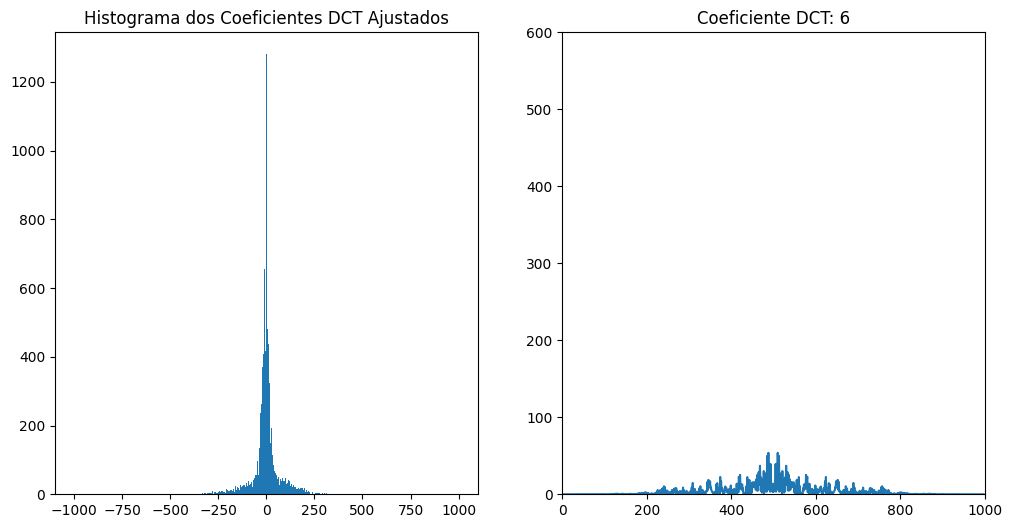

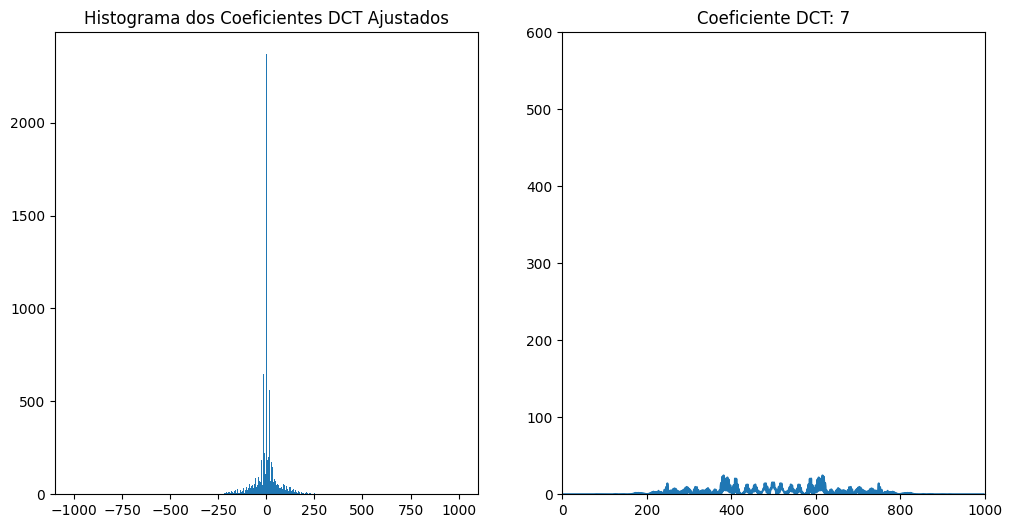

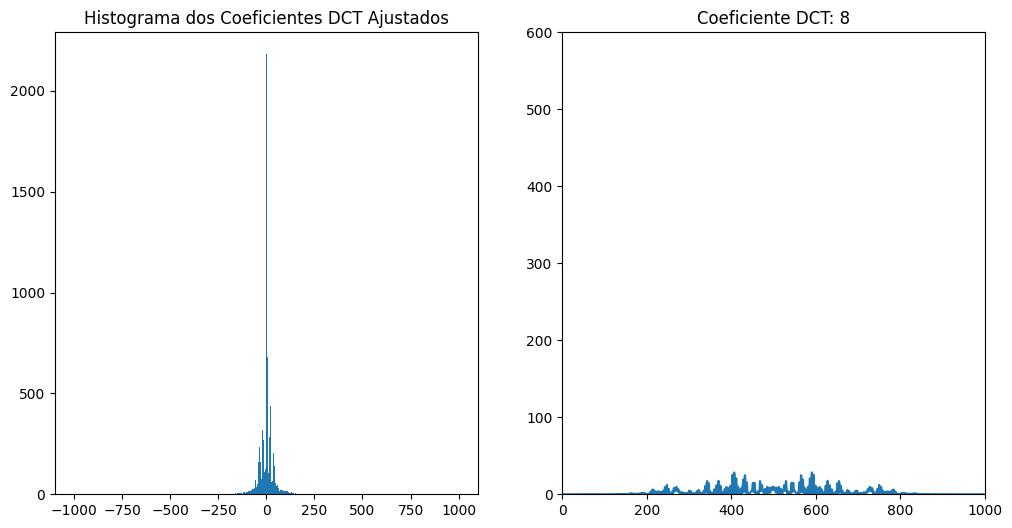

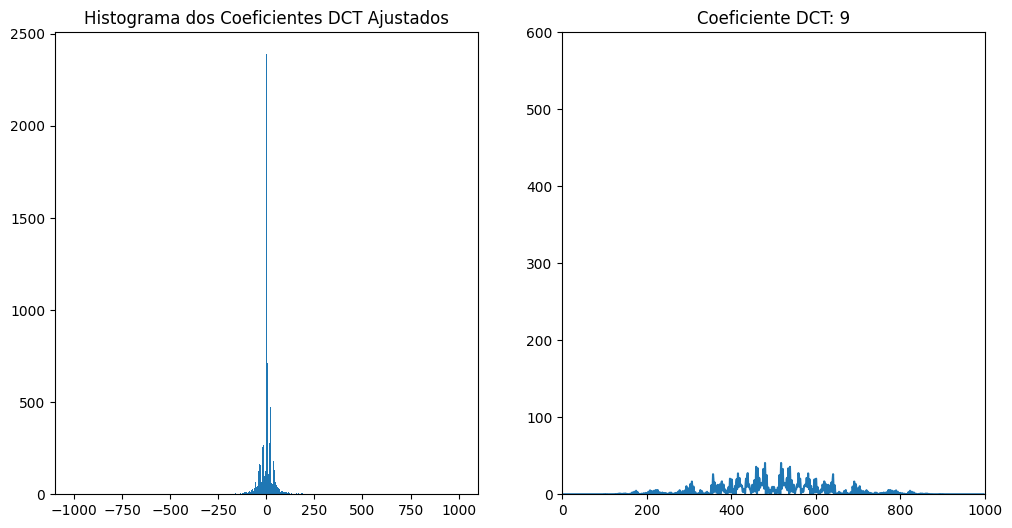

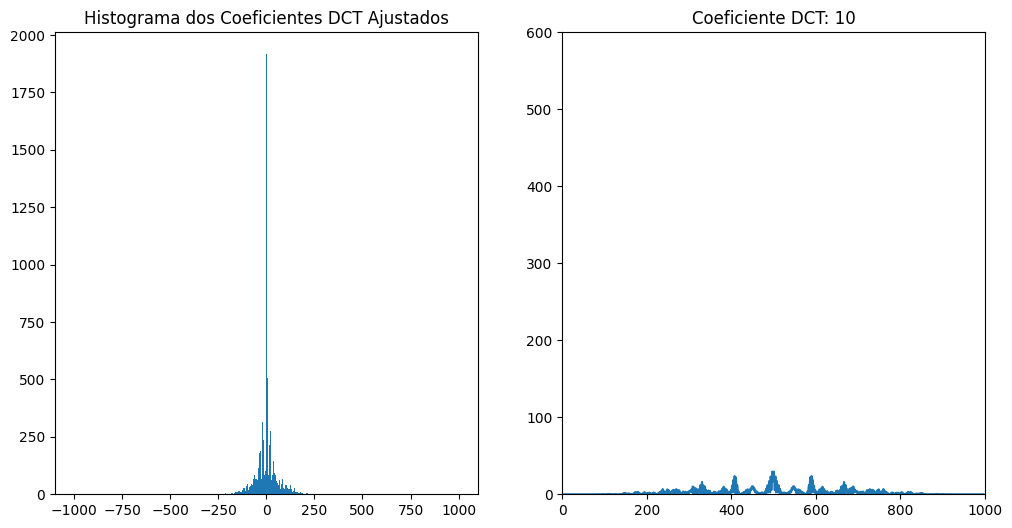

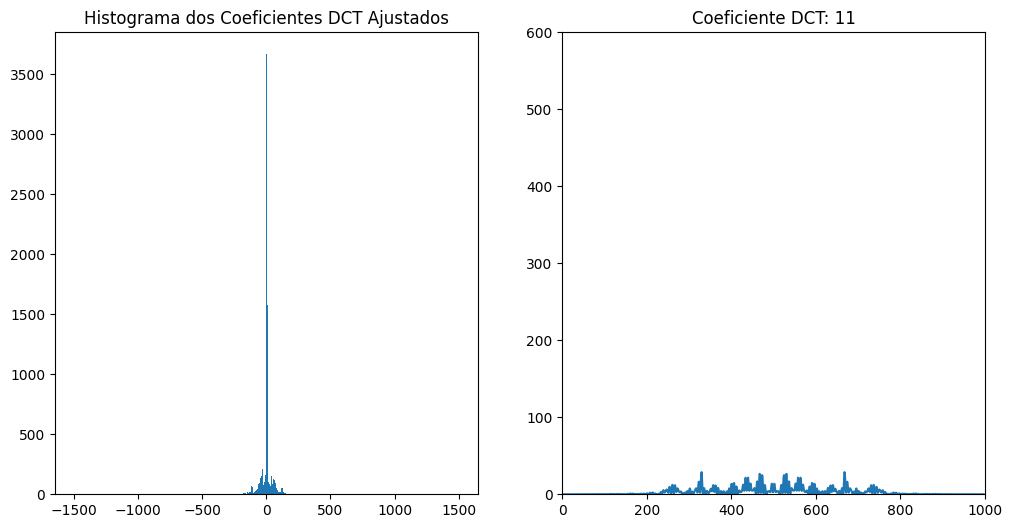

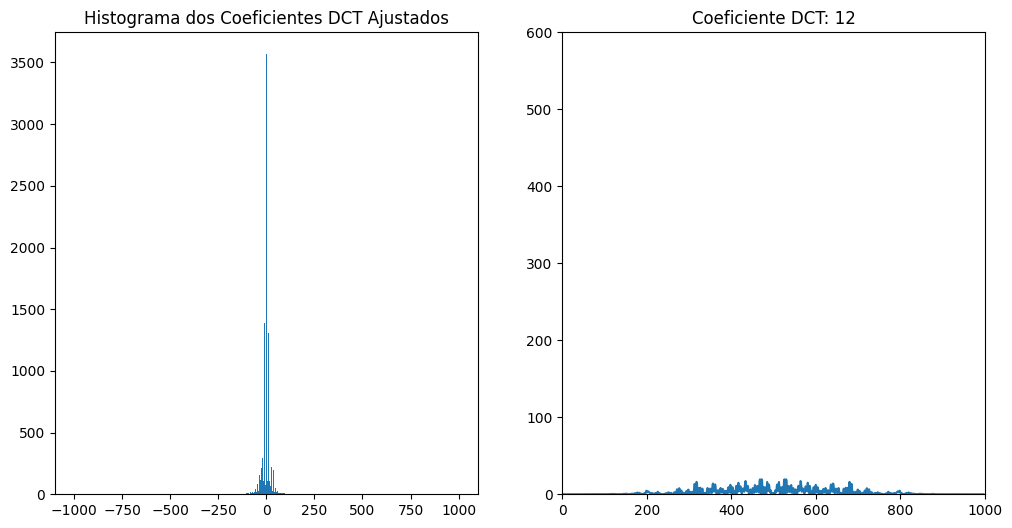

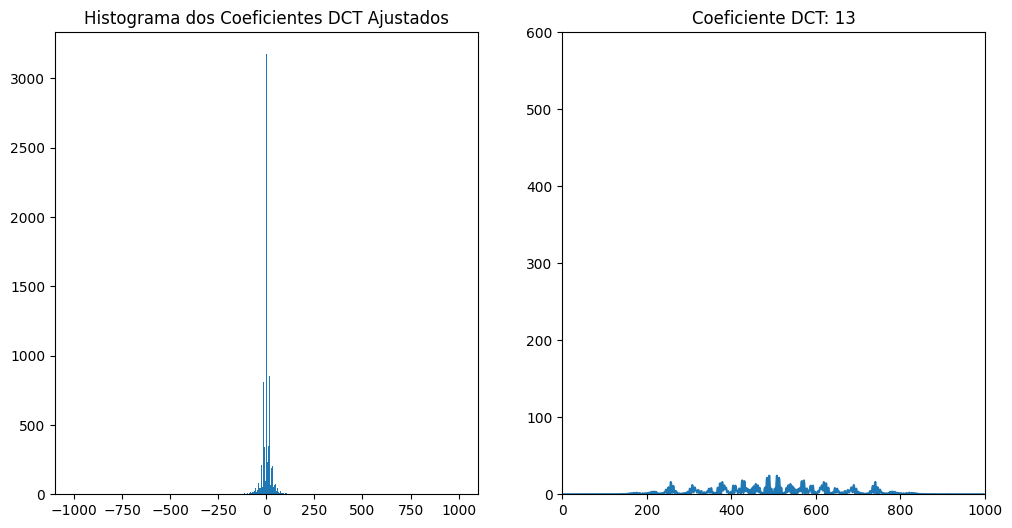

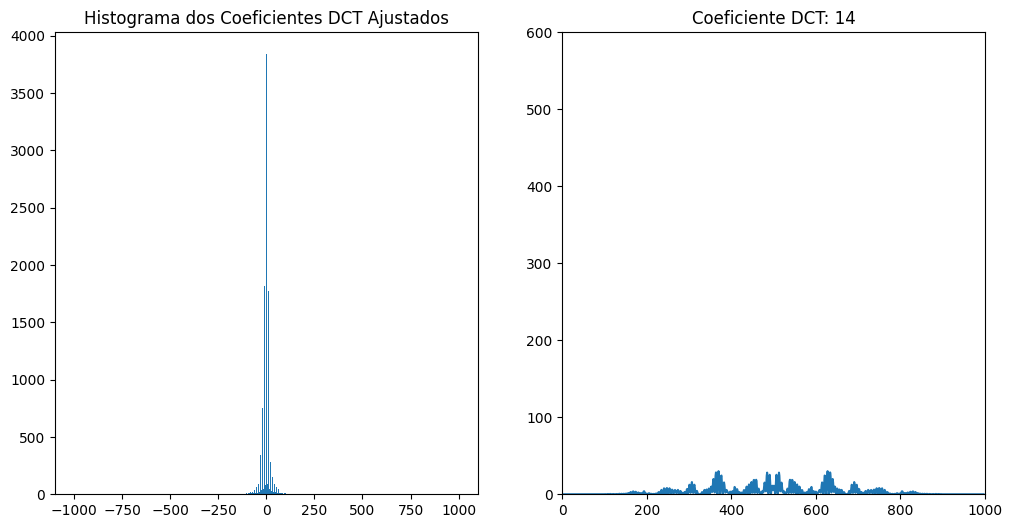

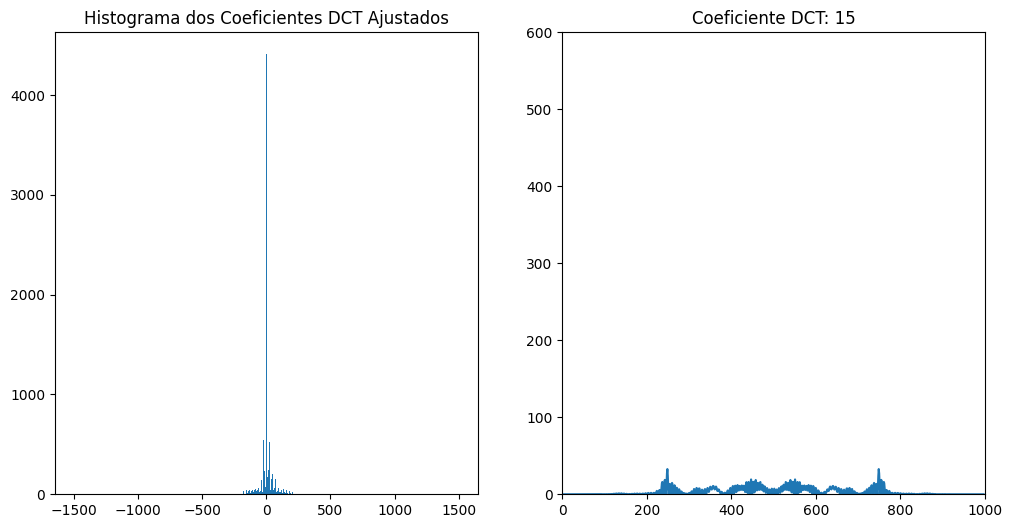

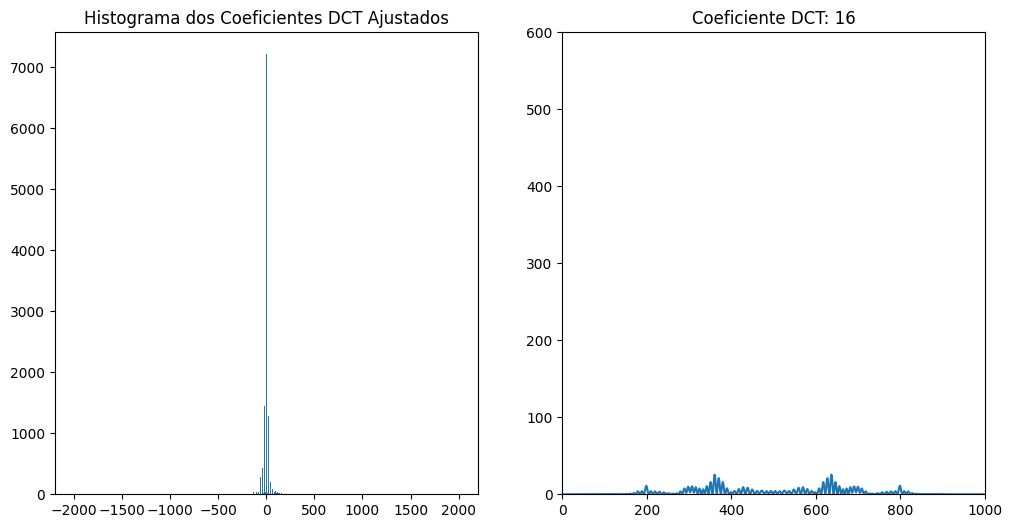

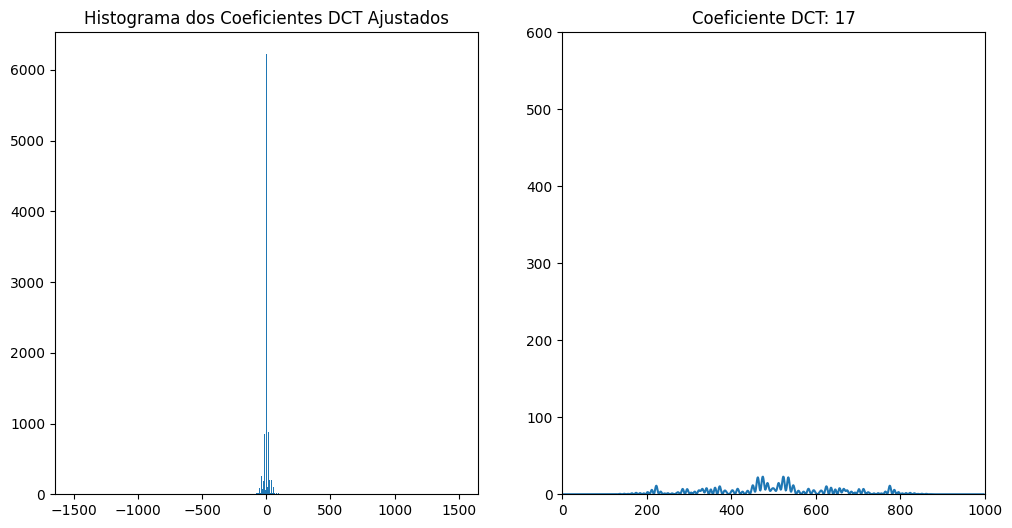

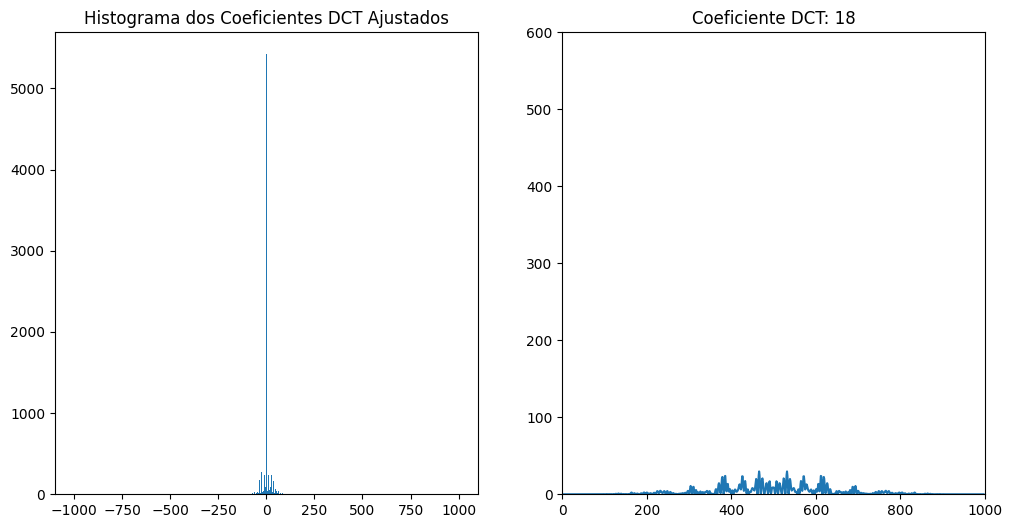

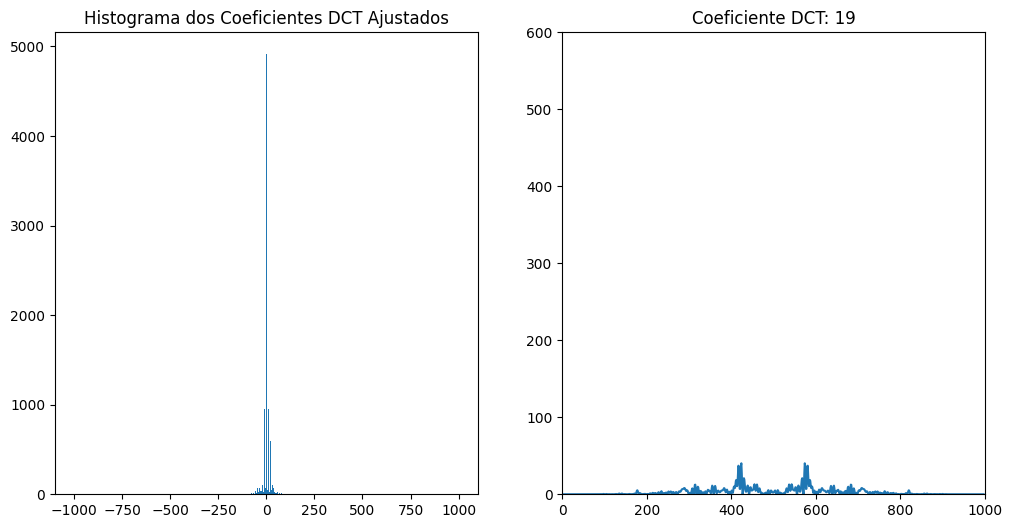

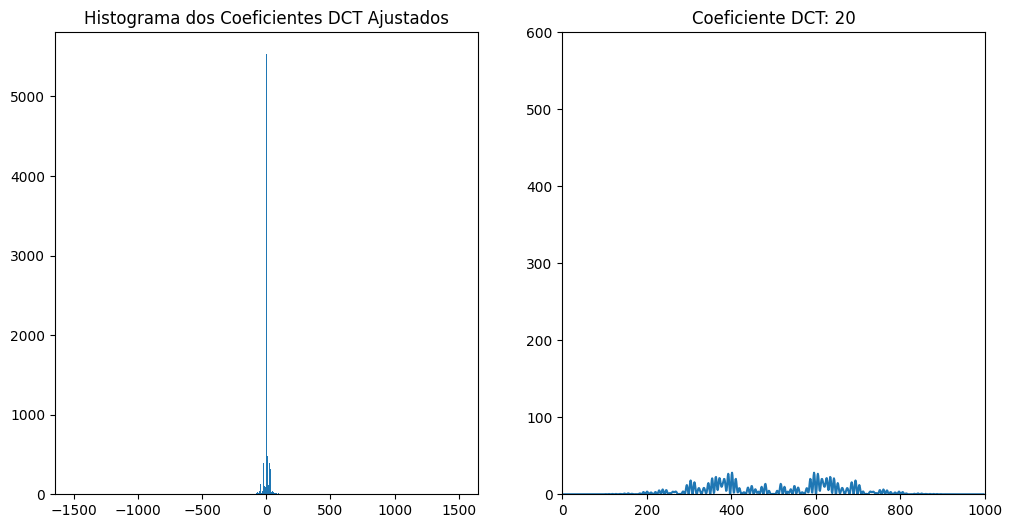

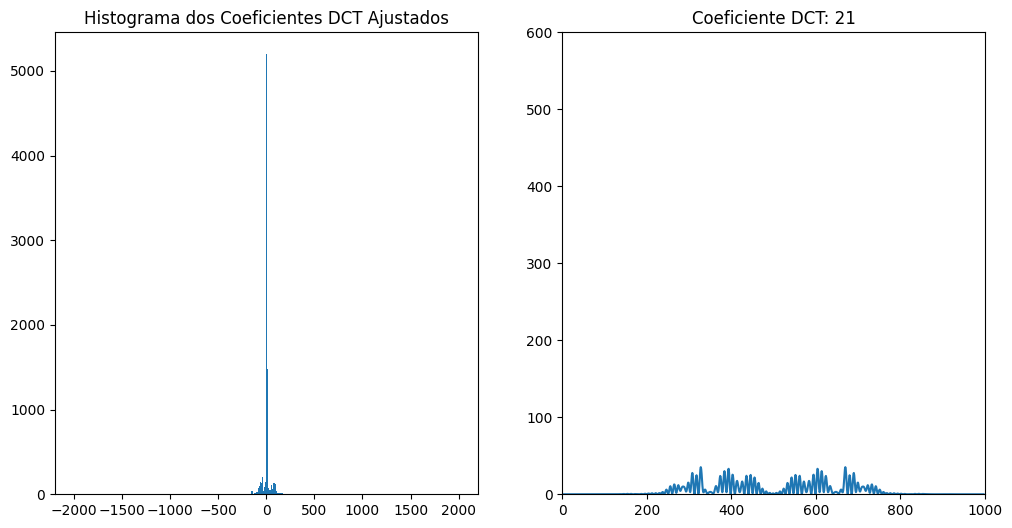

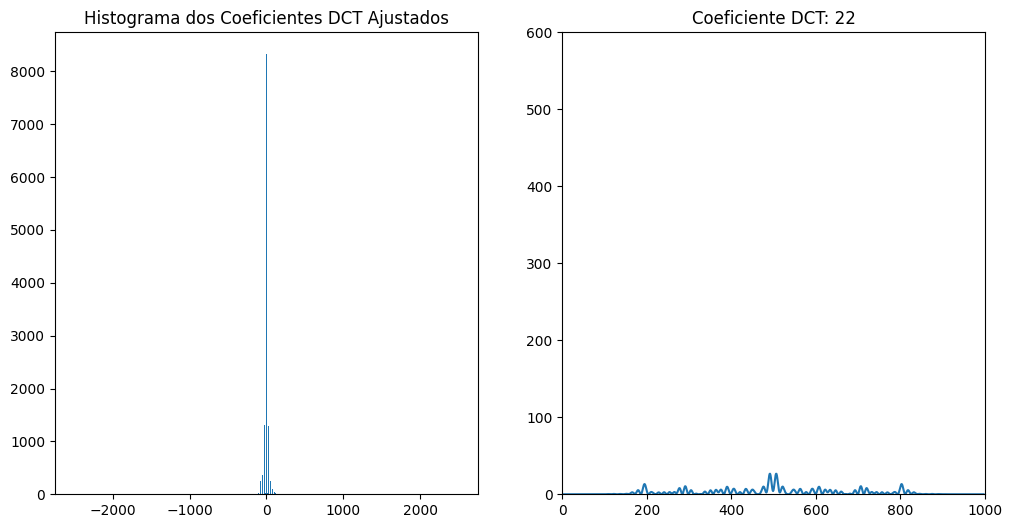

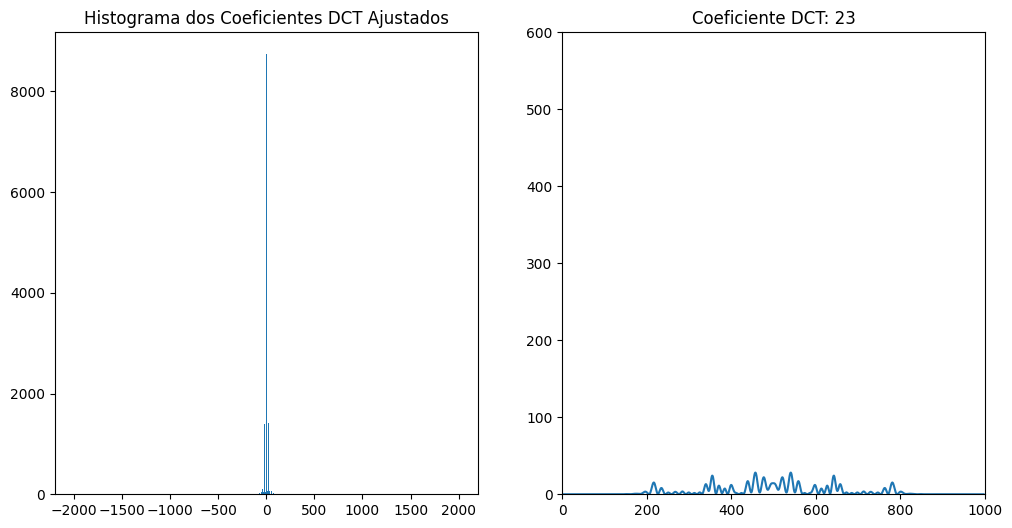

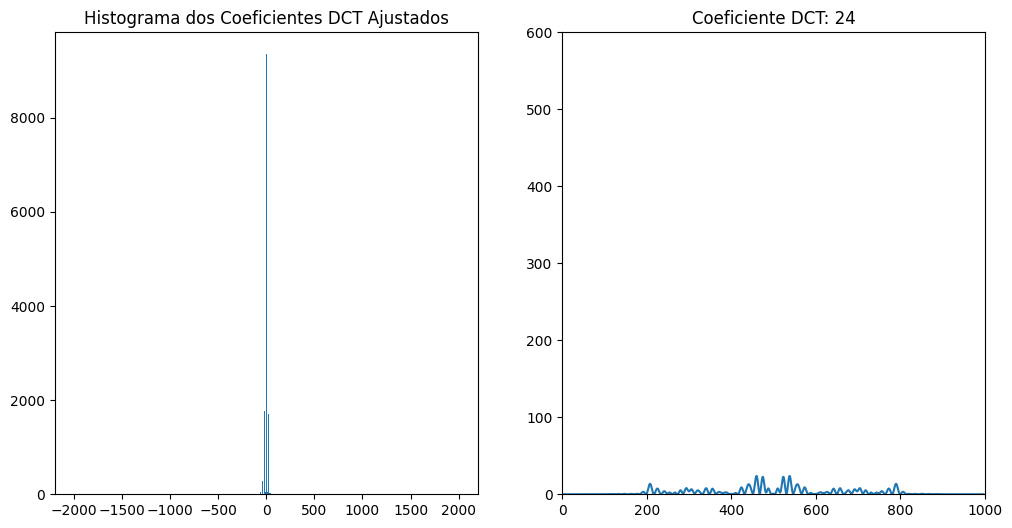

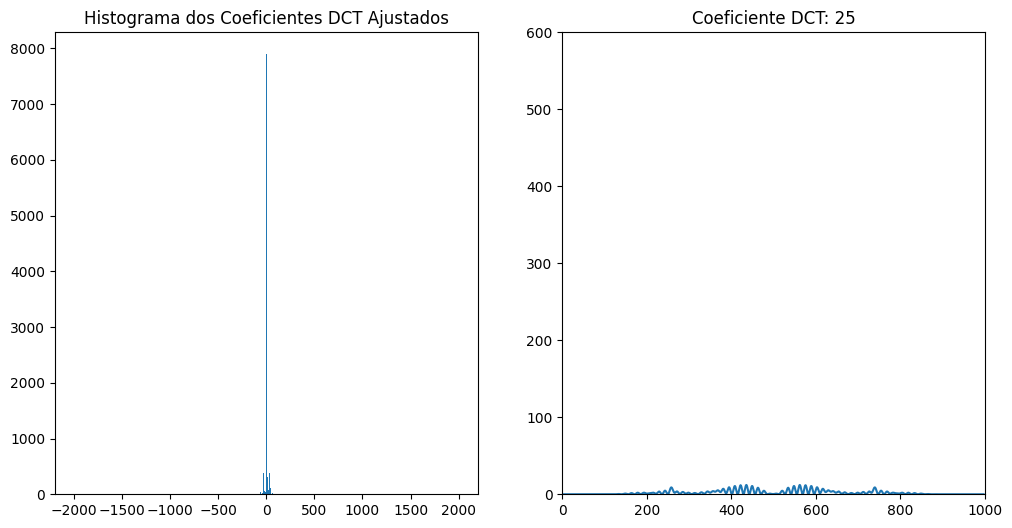

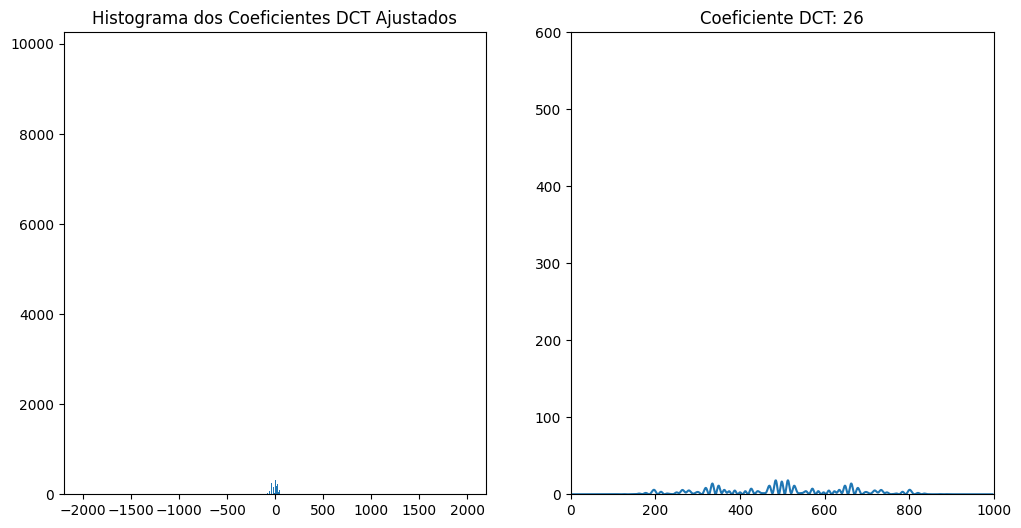

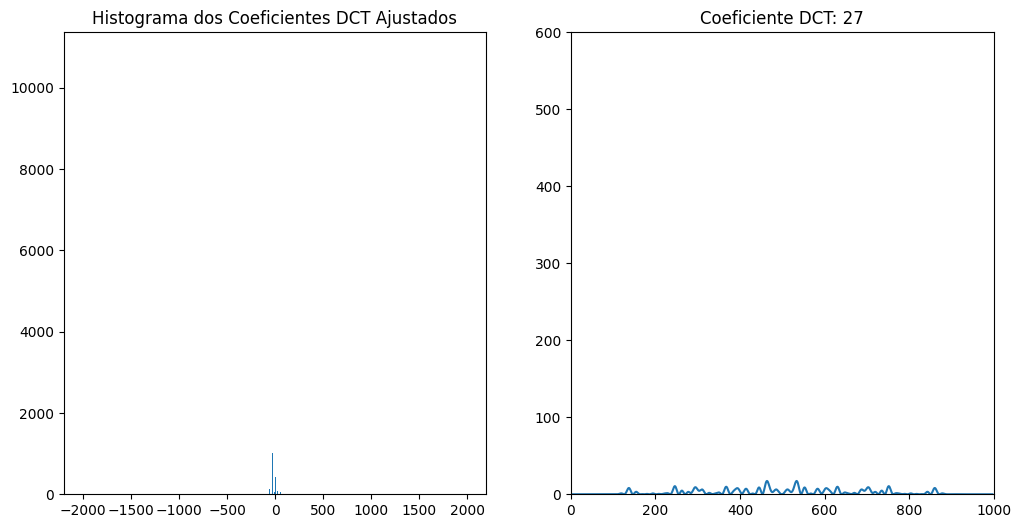

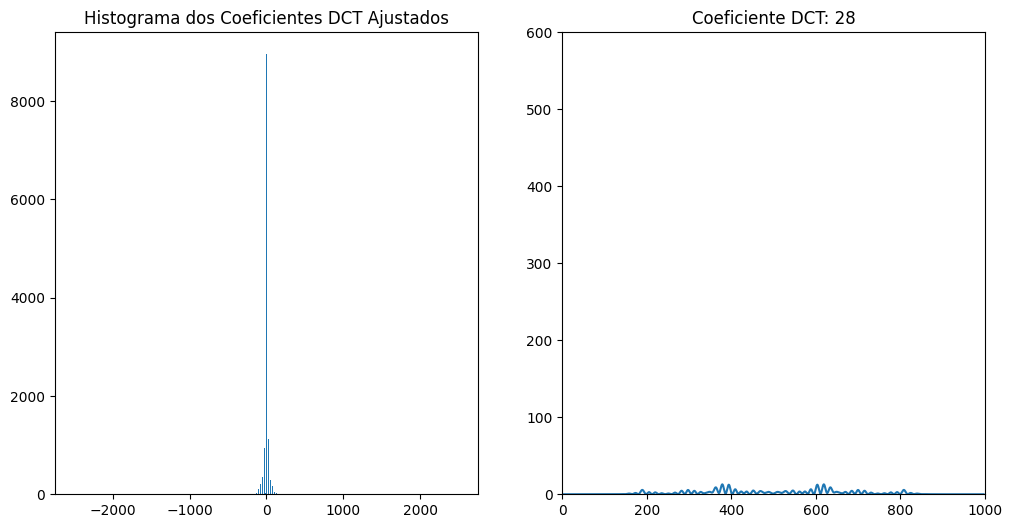

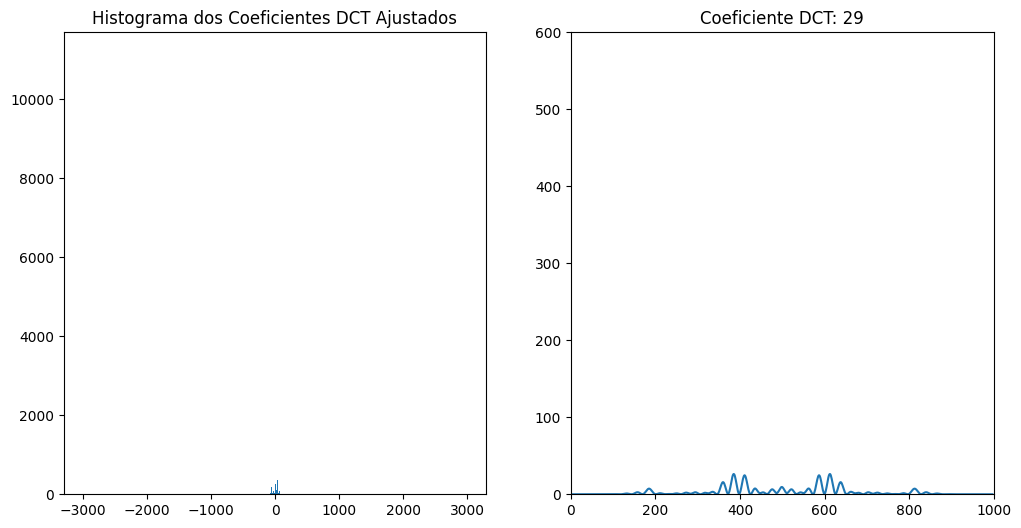

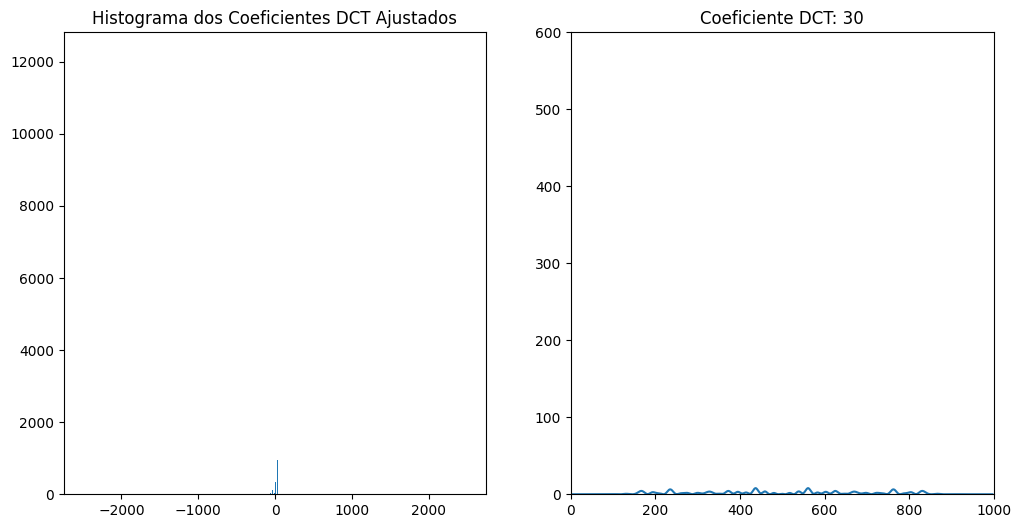

In [10]:
histdct('6.jpg', 1, 30)

# Inicialização de servidor web para visualização iterativa em HTML

In [ ]:
!cd output
!python3 -m http.server 4321

Serving HTTP on 0.0.0.0 port 4321 (http://0.0.0.0:4321/) ...
10.61.87.192 - - [21/Aug/2024 11:40:22] "GET / HTTP/1.1" 200 -
10.61.87.192 - - [21/Aug/2024 11:40:24] "GET /output/hist_1.html HTTP/1.1" 200 -
10.61.87.170 - - [21/Aug/2024 11:40:36] "GET / HTTP/1.1" 200 -
10.61.87.170 - - [21/Aug/2024 11:40:39] "GET /output/hist_1.html HTTP/1.1" 200 -
10.61.87.192 - - [21/Aug/2024 11:40:42] "GET /output/deteccao_1.html HTTP/1.1" 200 -
10.61.87.170 - - [21/Aug/2024 11:40:48] "GET /output/deteccao_1.html HTTP/1.1" 200 -
10.61.87.192 - - [21/Aug/2024 11:40:48] "GET /output/hist_2.html HTTP/1.1" 200 -
10.61.87.170 - - [21/Aug/2024 11:40:50] "GET /output/hist_2.html HTTP/1.1" 200 -
10.61.87.192 - - [21/Aug/2024 11:41:08] "GET /output/deteccao_1.html HTTP/1.1" 304 -
10.61.87.192 - - [21/Aug/2024 11:41:10] "GET /output/hist_1.html HTTP/1.1" 304 -
10.61.87.170 - - [21/Aug/2024 11:41:30] "GET /output/deteccao_1.html HTTP/1.1" 304 -
10.61.87.170 - - [21/Aug/2024 11:41:31] "GET /output/hist_1.html HTT